<a href="https://colab.research.google.com/github/Mansehaj-Singh/Drone-Orientation-Estimation/blob/main/Mansehaj_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading fast_v4.mat...
Training on cpu...
Epoch 1/100 | Loss: 0.026053
Epoch 10/100 | Loss: 0.008959
Epoch 20/100 | Loss: 0.002635
Epoch 30/100 | Loss: 0.002211
Epoch 40/100 | Loss: 0.001968
Epoch 50/100 | Loss: 0.001550
Epoch 60/100 | Loss: 0.001152
Epoch 70/100 | Loss: 0.001118
Epoch 80/100 | Loss: 0.001114
Epoch 90/100 | Loss: 0.000879
Epoch 100/100 | Loss: 0.001021

Final Test RMSE (qx, qy, qz): 0.019827


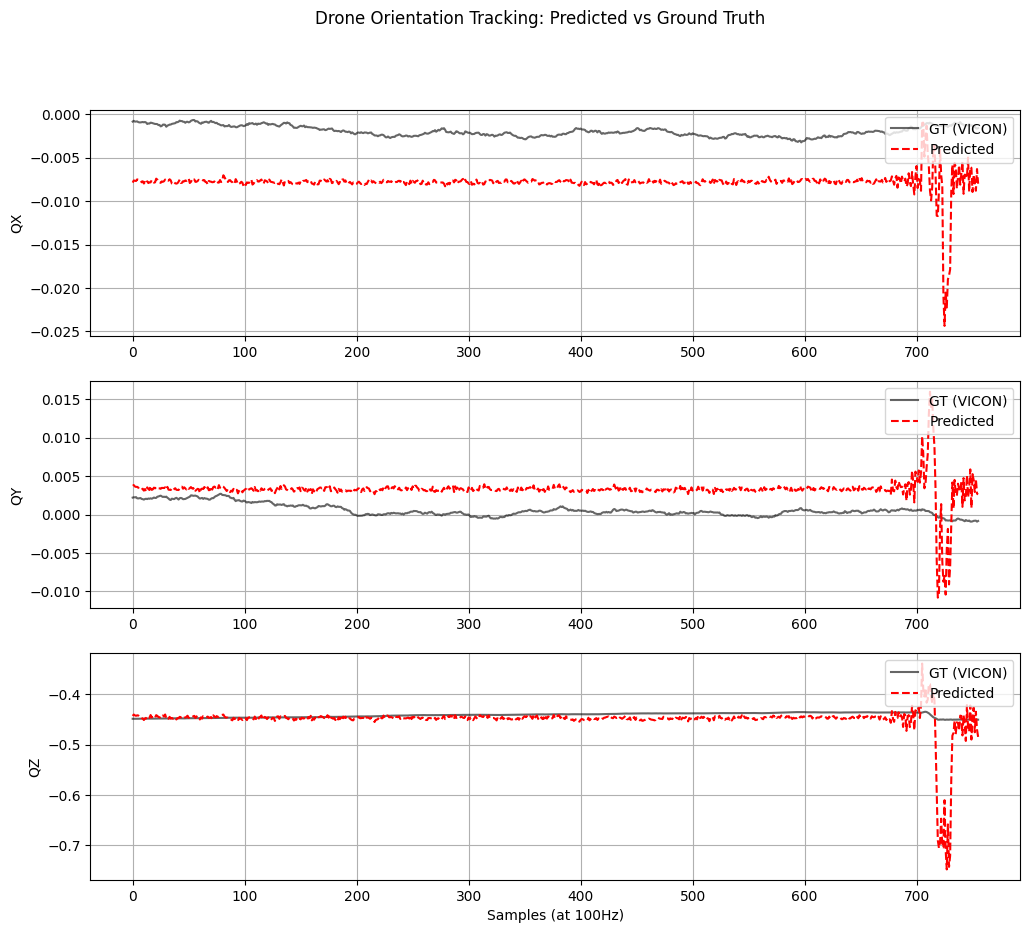

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    DATA_PATH = 'fast_v4.mat'
    SAMPLING_RATE = 100
    WINDOW_SIZE = 100    # 1 second of context
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    BATCH_SIZE = 64
    LR = 0.001
    EPOCHS = 100
    # Mapping for XS1: Accel (1:4), Gyro (4:7), Quat (10:14)
    IMU_IDX = list(range(1, 7))
    QUAT_IDX = list(range(10, 14))

# ==========================================
# 2. MODEL ARCHITECTURE (Dilated CNN)
# ==========================================
class DenoisingNet(nn.Module):
    def __init__(self):
        super(DenoisingNet, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(6, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=12, dilation=4),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=7, padding=48, dilation=16),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 3, kernel_size=1)
        )

    def forward(self, x):
        # x: (Batch, 6, Window) -> Returns correction for the last timestep
        return self.cnn(x)

# ==========================================
# 3. DATA PREPARATION
# ==========================================
def load_and_split_data():
    if not os.path.exists(Config.DATA_PATH):
        raise FileNotFoundError(f"Please upload {Config.DATA_PATH} to Colab first.")

    print(f"Loading {Config.DATA_PATH}...")
    mat = loadmat(Config.DATA_PATH)
    # The dataset uses 'XS1' as the key for Xsens sensor 1
    raw_data = mat['XS1']

    imu = raw_data[:, Config.IMU_IDX].astype(np.float32)
    quat = raw_data[:, Config.QUAT_IDX].astype(np.float32)

    # Sliding window to create training samples
    x_list, y_list = [], []
    for i in range(0, len(imu) - Config.WINDOW_SIZE, 5): # Step of 5 to speed up
        x_list.append(imu[i : i + Config.WINDOW_SIZE].T)
        y_list.append(quat[i + Config.WINDOW_SIZE])

    X = np.array(x_list)
    Y = np.array(y_list)

    # 80/20 Train/Test Split
    split_idx = int(len(X) * 0.8)

    train_ds = TensorDataset(torch.Tensor(X[:split_idx]), torch.Tensor(Y[:split_idx]))
    test_ds = (torch.Tensor(X[split_idx:]), torch.Tensor(Y[split_idx:]))

    return DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True), test_ds

# ==========================================
# 4. EXECUTION (TRAIN & TEST)
# ==========================================
def main():
    train_loader, (test_x, test_y) = load_and_split_data()
    model = DenoisingNet().to(Config.DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LR)
    criterion = nn.MSELoss()

    print(f"Training on {Config.DEVICE}...")
    for epoch in range(1, Config.EPOCHS + 1):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(Config.DEVICE), batch_y.to(Config.DEVICE)

            optimizer.zero_grad()
            preds = model(batch_x)[:, :, -1] # Prediction for the latest sample

            # The model predicts the vector part of the quaternion (qx, qy, qz)
            loss = criterion(preds, batch_y[:, 1:])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{Config.EPOCHS} | Loss: {epoch_loss/len(train_loader):.6f}")

    # Testing phase
    model.eval()
    with torch.no_grad():
        test_preds = model(test_x.to(Config.DEVICE))[:, :, -1].cpu().numpy()
        test_targets = test_y[:, 1:].numpy()

    # Metrics
    rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
    print(f"\nFinal Test RMSE (qx, qy, qz): {rmse:.6f}")

    # Visualization
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    components = ['QX', 'QY', 'QZ']
    time_steps = np.arange(len(test_targets))[:1000] # Show first 10 seconds

    for i in range(3):
        axes[i].plot(time_steps, test_targets[:1000, i], label='GT (VICON)', color='black', alpha=0.6)
        axes[i].plot(time_steps, test_preds[:1000, i], label='Predicted', color='red', linestyle='--')
        axes[i].set_ylabel(components[i])
        axes[i].legend(loc='upper right')
        axes[i].grid(True)

    plt.xlabel("Samples (at 100Hz)")
    plt.suptitle("Drone Orientation Tracking: Predicted vs Ground Truth")
    plt.show()

if __name__ == "__main__":
    main()